# Lyrical Topic Extraction

__Final Project:__ CSCA 5632 - Unsupervised Algorithms in Machine Learning

James P. Imes

# Introduction

In this project, Topic Frequency-Inverse Document Frequency (TF-IDF) and Non-negative Matrix Factorization (NMF) will be used to extract the topic of songs based on their lyrics. The same techniques will be used to preprocess the data to remove some predominantly non-English songs from our dataset.

For completeness, a second model is built with a matrix generated using Token Count (instead of TF-IDF), decomposed with Latent Dirichlet Allocation (instead of NMF).

The techniques used in this project could be used to automate themed playlists.

__Content warning:__ This project uses lyrics that have not been edited (beyond some preprocessing below and in the original dataset). There is some profanity in the data, including some slurs (e.g., the use of the N-word, presumably in hip hop songs). To avoid affecting the model's results, they have not been removed. I will provide another content warning before the sections of this report where those words are seen.

In [1]:
# # These corpuses must be downloaded.
# import nltk
# nltk.download('words')
# nltk.download('stopwords')

In [2]:
import sqlite3
from itertools import combinations

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from nltk.corpus import stopwords
from nltk.corpus import words as nltk_english_words

In [3]:
# Preconfigure parameters for our dataset.
n_dataset_small = 5000
random_state = 42

# Data Sources

The [Million Song Dataset](http://millionsongdataset.com/) (MSD), provided by Thierry Bertin-Mahieux, Daniel P.W. Ellis, Brian Whitman, and Paul Lamere, is an amazing dataset for analyzing music. The primary data used here is the [musiXmatch Dataset](http://millionsongdataset.com/musixmatch/)\*\*, a collaboration between MSD and musiXmatch, being a count of words in the lyrics to each song (a word bag approach), rather than the full lyrics of each song, which could not be distributed for copyright reasons.

Also used was the [list of unique tracks](http://millionsongdataset.com/sites/default/files/AdditionalFiles/unique_tracks.txt), with track id, song id, artist name, and song title -- primarily for examining the results. (This file was modified for this project to add column headers.)

(\*\*[Here](http://millionsongdataset.com/sites/default/files/AdditionalFiles/mxm_dataset.db) is a direct link to the SQLite database of the word counts in lyrics.)

# Exploratory Data Analysis and Preprocessing

In [4]:
# Artist, Song Title, etc.
song_info = pd.read_csv(r'C:\users\james\downloads\unique_tracks.txt', delimiter='<SEP>', engine='python')

In [5]:
# musixMatch SQLite database (lyrics)
words_database_fp = r'C:\users\james\downloads\mxm_dataset.db'

The lyrics dataset includes only a subset of the songs in the "Million Song Dataset". I did some preprocessing outside this notebook to extract all `track_id` whose lyric information was available and saved it to `track_ids.csv`.

In [6]:
available_track_ids = pd.read_csv(r'data\track_ids.csv')
song_info = available_track_ids.merge(song_info, on='track_id', how='left')
song_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237662 entries, 0 to 237661
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   track_id     237662 non-null  object
 1   song_id      237662 non-null  object
 2   artist_name  237662 non-null  object
 3   song_title   237659 non-null  object
dtypes: object(4)
memory usage: 7.3+ MB


The raw dataset is a table of word counts in song lyrics (a "bag of words"), with features `track_id`, `word`, and `count` -- and with each row representing a single unique word in a given track, and how many times it appears in that track:

In [7]:
with sqlite3.connect(words_database_fp) as cnx:
    track_id = "TRMMNWF128F42889CB"  # Sample
    sample = pd.read_sql_query(f"SELECT * FROM lyrics WHERE track_id={track_id!r}", cnx)

sample.head()

,track_id,mxm_tid,word,count,is_test
0,TRMMNWF128F42889CB,6975591,i,1,0
1,TRMMNWF128F42889CB,6975591,the,6,0
2,TRMMNWF128F42889CB,6975591,you,5,0
3,TRMMNWF128F42889CB,6975591,to,2,0
4,TRMMNWF128F42889CB,6975591,and,15,0


To preprocess the data into a form that can be plugged into sklearn's `TfidfVectorizer`, all rows for a given track will be compiled into a single row in a new table, with each row containing all of the text for that track, repeating each `word` by its `count` -- e.g., `'i the the the the the the you you you you you...'`. 

(We *could* build the TD-IDF matrix directly from the word counts, which would probably be more efficient in terms of compute, but this requires less code and allows us to rely on sklearn's `TfidfVectorizer`.)

In [8]:
words_to_replace = {
    'ohh': 'oh',  # Different spellings of the same 'word'.
    'ooh': 'oh',
}
def compile_word_data(lyric_df, max_repeat = None, drop_words=None) -> str:
    """
    Takes a query result from the `mxm_dataset.db` data for a single track.
    Returns the combined text, the total word count, and the unique word count.
    :param max_repeat: (Optional) Cap the number of times a word may be repeated.
     (Warning: Will overwrite the `'count'` feature in the original dataframe.)
    """
    if max_repeat is not None:
        lyric_df['count'] = max_repeat
    lyric_df['word'] = lyric_df['word'].replace(words_to_replace)
    if drop_words is not None:
        lyric_df = lyric_df[~lyric_df['word'].isin(drop_words)].copy()
    lyric_df['compiled_text'] = (lyric_df['word'] + ' ') * lyric_df['count']
    return ''.join(lyric_df['compiled_text']), lyric_df['count'].sum(), len(lyric_df['word'])

In [9]:
text, word_count_all, word_count_unique = compile_word_data(sample, max_repeat=None, drop_words=None)
print("Example preprocessing for one track:")
print(f"{word_count_all} total words ({word_count_unique} unique)", end='\n\n')
print('Compiled text:\n\n', text)

Example preprocessing for one track:
308 total words (97 unique)

Compiled text:

 i the the the the the the you you you you you to to and and and and and and and and and and and and and and and me me me me me me me me it not not not not not not in is of of your your your your that that that that that do do do on on on on on on on on on on on on are we we we we we we we will all for for for be be be be be love so know know know know know this but with with with with with with with with with like now now now now now now come come come come come come come come come come come up oh oh oh oh oh oh oh oh oh oh oh oh oh oh oh oh oh one one they they they they they they they out get if from from from from from want want want want let let let let let let make day back back back back back back back back back back back back heart our our our our die live well wo wo wo wo about noth were home home home home home home home home home home home home run them them them them their their their their th

### Stemmed data
Note that the lyrics include words like `'harmoni'` and '`everybodi'`, which are not real words. The maintainers of the dataset had preprocessed the data by 'stemming' the words, such that (for example) `'harmony'` and `'harmonies'` would be considered the same word.

## Extracting a subset of the dataset

Using the full lyrics dataset is impractical for this project, as it contains over 200,000 unique tracks. Instead, this project will use a random sample.

In [10]:
def get_dataset(available_tracks, n_tracks: int=None, random_state=None, selected_tracks=None, track_info=None, max_repeat=None, drop_words=None):
    """
    Sample and compile a dataset of size `n_tracks` from the database.
    :param n_tracks: The number of tracks to include in the dataset,
     randomly sampled from all available.
    :param random_state: Same as used in `df.sample()` in pandas.
    :param selected_tracks: (Optional alternative to `n_tracks`) Specify the
     `track_id` of all songs desired in the dataset.
    :param track_info: (Optional) Dataframe of track info (title, artist, etc.)
     that can be merged into the dataset on field `track_id`.
    :param max_repeat: Same effect as in `compile_word_data()`.
    :param drop_words: Same effect as in `compile_word_data()`.
    """
    if selected_tracks is None:
        selected_tracks = available_tracks.sample(n=n_tracks, random_state=random_state)
    cnx = sqlite3.connect(words_database_fp)
    compiled = {'track_id': [], 'text': [], 'word_count_all': [], 'word_count_unique': []}
    for track_id in selected_tracks['track_id']:
        query_result = pd.read_sql_query(f"SELECT * FROM lyrics WHERE track_id={track_id!r}", cnx)
        text, word_count_all, word_count_unique = compile_word_data(
            query_result, max_repeat=max_repeat, drop_words=drop_words
        )
        compiled['track_id'].append(track_id)
        compiled['text'].append(text)
        compiled['word_count_all'].append(word_count_all)
        compiled['word_count_unique'].append(word_count_unique)
    dataset = pd.DataFrame(compiled)
    if track_info is not None:
        dataset = dataset.merge(track_info, on='track_id', how='left')
    return dataset

In [11]:
dataset1 = get_dataset(available_track_ids, n_tracks=n_dataset_small, random_state=random_state, track_info=song_info)

In [12]:
dataset1.head()

,track_id,text,word_count_all,word_count_unique,song_id,artist_name,song_title
0,TRCIVZN128F147ACA3,i i i i i i i i i i i i i i i i i i i the the ...,301,131,SORIXFI12A6D4F8B0D,The Jazz Butcher Conspiracy,Diamorphine
1,TRAIULP128F4295970,i the the the the the the the the the you you ...,179,72,SOORARD12A8C140250,John Prine,You Mean So Much To Me
2,TRZYFWN12903CEF239,i i i i i i i i i i i i i i i i i i i i i i i ...,386,80,SOWDQEY12AC90971FA,Color Me Badd,On My Mind (LP Version)
3,TRZKWZC128F93038EB,i i i i i the the you you you you to to to to ...,116,67,SOTOQEZ12AF72A8DEB,Revive,The Truth Is
4,TRVETVN128F147AD96,i i i the the the the the the you you you to t...,145,55,SOMYGJP12A58A7C311,The Puppini Sisters,Jeepers Creepers


In [13]:
n_tracks_total = len(song_info)
unique_artists_total = len(song_info['artist_name'].unique())

n_tracks_subset = len(dataset1)
unique_artists_subset = len(dataset1['artist_name'].unique())
print(f"{n_tracks_total} tracks in full dataset, with {unique_artists_total} unique artists.")
print(f"{n_tracks_subset} tracks in subset dataset, with {unique_artists_subset} unique artists.")

237662 tracks in full dataset, with 22821 unique artists.
5000 tracks in subset dataset, with 3849 unique artists.


There are no duplicate songs in our subset (judging from artist name and song title).

In [14]:
dataset1[dataset1.duplicated(subset=['artist_name', 'song_title'])].info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   track_id           0 non-null      object
 1   text               0 non-null      object
 2   word_count_all     0 non-null      int64 
 3   word_count_unique  0 non-null      int64 
 4   song_id            0 non-null      object
 5   artist_name        0 non-null      object
 6   song_title         0 non-null      object
dtypes: int64(2), object(5)
memory usage: 0.0+ bytes


In fact, there are only a 8 duplicated songs in the whole original dataset.

In [15]:
song_info[song_info.duplicated(subset=['artist_name', 'song_title'])]

,track_id,song_id,artist_name,song_title
73154,TRNMCGG128F92DFF82,SOTPAUW12A8C143BA9,The Script,The Man Who Can't Be Moved
97241,TRTTXOV128F930DD34,SOEBNTB12AB01845AA,Mungo Jerry,Baby Jump
145185,TRZISXY128F92DEA63,SOFPQLD12AB017D85A,Sash!,Mysterious Times
160746,TRESRKO12903CAFA55,SOTFPPY12AB0183D2F,Freemasons,When You Touch Me
165325,TRHQTKR128F9310123,SOGGHXJ12AB0183B98,Gillan,On The Rocks
202894,TRLEANJ128F92F34E2,SOEDGPA12AAF3B4122,Little Richard,Tutti Frutti
209092,TRBCDDD128F92D164D,SOSXKGQ12A8C142523,Gillan,Bite The Bullet
219031,TRHPHBA128F92DFDB3,SOJESOT12AAF3B4E36,Rose Elinor Dougall,Another Version Of Pop Song


### Examining word counts

In [16]:
dataset1_without_stopwords = get_dataset(available_track_ids, n_tracks=n_dataset_small, random_state=random_state, track_info=song_info, drop_words=stopwords.words())

In [17]:
wca = dataset1['word_count_all']
wcu = dataset1['word_count_unique']
wca_stop = dataset1_without_stopwords['word_count_all']
wcu_stop = dataset1_without_stopwords['word_count_unique']

print(f"Mean word count (including duplicate words): {wca.mean():.1f}")
print(f"Median word count (including duplicate words): {wca.median()}")
print(f"Minimum word count (including duplicate words): {wca.min()}")
print(f"Maximum word count (including duplicate words): {wca.max()}")

print(f"Mean word count (unique words): {wcu.mean():.1f}")
print(f"Median word count (unique words): {wcu.median()}")
print(f"Minimum word count (unique words): {wcu.min()}")
print(f"Maximum word count (unique words): {wcu.max()}")


print(f"Mean word count (including duplicate words, no stop words): {wca_stop.mean():.1f}")
print(f"Median word count (including duplicate words, no stop words): {wca_stop.median()}")
print(f"Minimum word count (including duplicate words, no stop words): {wca_stop.min()}")
print(f"Maximum word count (including duplicate words, no stop words): {wca_stop.max()}")

print(f"Mean word count (unique words, no stop words): {wcu_stop.mean():.1f}")
print(f"Median word count (unique words, no stop words): {wcu_stop.median()}")
print(f"Minimum word count (unique words, no stop words): {wcu_stop.min()}")
print(f"Maximum word count (unique words, no stop words): {wcu_stop.max()}")

Mean word count (including duplicate words): 210.5
Median word count (including duplicate words): 184.0
Minimum word count (including duplicate words): 1
Maximum word count (including duplicate words): 3288
Mean word count (unique words): 79.1
Median word count (unique words): 73.0
Minimum word count (unique words): 1
Maximum word count (unique words): 536
Mean word count (including duplicate words, no stop words): 67.0
Median word count (including duplicate words, no stop words): 58.0
Minimum word count (including duplicate words, no stop words): 0
Maximum word count (including duplicate words, no stop words): 1010
Mean word count (unique words, no stop words): 37.0
Median word count (unique words, no stop words): 32.0
Minimum word count (unique words, no stop words): 0
Maximum word count (unique words, no stop words): 360


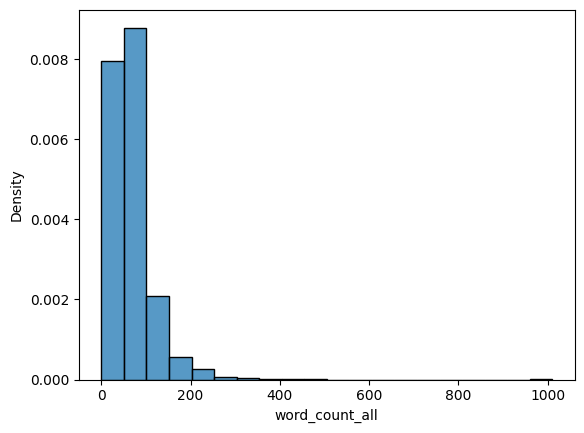

In [18]:
sns.histplot(dataset1_without_stopwords, x='word_count_all', bins=20, stat='density')
plt.show()

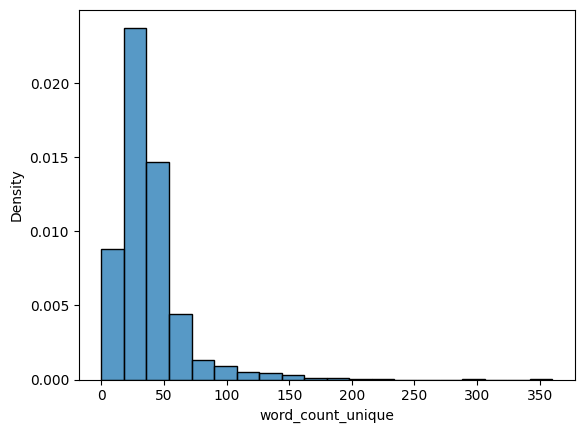

In [19]:
sns.histplot(dataset1_without_stopwords, x='word_count_unique', bins=20, stat='density')
plt.show()

Some tracks in the dataset use very few words. In the subset below with fewer than 5 unique words, it seems there are a large number of non-English songs (which will be dealt with later), but the few English songs still seem to have 'meaningful' lyrics, so we won't pre-filter our dataset by text length.

*__Content warning:__ Profanity.*

In [20]:
sparse_tracks = dataset1[dataset1['word_count_unique'] < 5]
print("Number of tracks with fewer than 5 unique words:", len(sparse_tracks))
sparse_tracks

Number of tracks with fewer than 5 unique words: 16


,track_id,text,word_count_all,word_count_unique,song_id,artist_name,song_title
344,TRNGMZV128E0795C93,que t vez cada,4,4,SOSNVUF12A67ADD461,Los Secretos,Cada vez que tu me miras
539,TRWZFMH12903CF4237,tak tak ku,3,2,SORXYZN12AC468D861,Padi,Demi Cinta
820,TROOUTV128F428E8A8,the in night walk,4,4,SOVADPE12A6D4F811F,Paul Hardcastle,Walk In The Night
1065,TRGDEAJ12903CDB72C,in in chorus io gloria gloria,6,4,SOFZXIO12AB018AED3,Cleopatra,Adeste Fideles
1271,TRSTVLY128F92FE2B8,the is now time,4,4,SOSRQFL12A8C143945,The Crystal Method,Now Is The Time
1351,TRIAFZO128F1487F92,om,1,1,SOWNALX12A58A7D32C,Biddu,Gayatri Mantra
1385,TRDTJHY12903CB1684,si mare,2,2,SOJQFWE12AB0187746,Stoa,Nubibus Atris
2156,TRMLOGP128F930BE4A,i i i i the the the the am am am am,12,3,SOPAJGQ12AB017F47D,Black Moth Super Rainbow,I Am The Alphabet
2496,TRDXPYA128F427A84C,a a a a de de de de de de de de de de de de de...,32,3,SOWGHQX12A8C137CD5,Deep Forest,Bohemian Ballet
2609,TRYHAXC12903CC2BC6,soy soy soy soy tiempo otro otro,7,3,SOZQVPK12AB01868FB,Arma Blanca,El Extranjero


# Model Game Plan

The combination of [Topic Frequency-Inverse Document Frequency (TF-IDF)](https://www.geeksforgeeks.org/understanding-tf-idf-term-frequency-inverse-document-frequency/#) and [Non-negative Matrix Factorization (NMF)](https://iq.opengenus.org/topic-modeling-nmf/) is a common method to extract topics of text-based documents and will be the approach here.
* sklearn's `TfidfVectorizer` uses TF-IDF to create a "term-document matrix" (TDM) of the words ("terms") that appear in each song ("document") -- encoding the weighting (i.e., "importance") of each word for a given song.
  * All models will use the `stop_words='english'` parameter in `TfidfVectorizer` for rudimentary handling of stop words. (This will have the side-effect of simplifying the removal of non-English songs from the dataset.)
* sklearn's `NMF` decomposes the TDM to extract the topic of each song. NMF is appropriate for topic extraction because a word either appears in a document or it does not, and it is therefore impossible for negative values to find their way into the TDM (a requirement for NMF).

There is no ground truth in the dataset, and evaluation will therefore be more difficult. The initial assessment of the results will be subjective, looking for "commonality" in the __*n*__ top words in each topic. After a baseline topic extraction model is achieved, hyperparameters will be tuned to even out the distribution of the __*n*__ top words in each extracted topic, so that topics are less skewed by one or two words.

Finally, a larger dataset will be sampled, this time sampling *artists* rather than *individual tracks* -- in order to get a large number of artists' complete discography (as far as is represented in the available dataset). The goal for that step will be to examine artists who prefer to sing about one particular topic.

And for completeness, a second model is built with a matrix generated using Token Count (instead of TF-IDF), decomposed with Latent Dirichlet Allocation (instead of NMF).

A __U_Mass coherence score__ will also be calculated to assess the models. However, coherence is not a perfect metric in topic extraction, and human judgment is often useful ([citation](https://medium.com/blend360/topic-modelling-a-comparison-between-lda-nmf-bertopic-and-top2vec-part-i-3c16372d51f0))


## Initial NMF Model

To start, NMF will decompose the TDM to 20 components.

*__Content warning:__ In the section below, profanity and slurs are visible in the results.*

In [21]:
vec = TfidfVectorizer(input='content', stop_words='english')
dt_mtx = vec.fit_transform(dataset1['text'])
feature_names = vec.get_feature_names_out()

nmf = NMF(n_components=20, max_iter=500)
nmf_mtx = nmf.fit_transform(dt_mtx)
pred = np.argmax(nmf_mtx, axis=1)

In [22]:
# The code for these two function was modified from this example provided by the sklearn team:
# https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html
def get_top_words(model, feature_names, n_top_words: int):
    """Extract the top words for each topic."""
    topic_words = []
    for topic in model.components_:
        top_words_ind = topic.argsort()[-n_top_words:]
        top_words = feature_names[top_words_ind]
        weights = topic[top_words_ind]
        topic_info = {'top_words': top_words, 'weights': weights}
        topic_words.append(topic_info)
    return topic_words


def plot_top_words(model, feature_names, n_top_words: int, plot_rows: int, plot_cols: int, title=None, norm_weights=False):
    """Plot the top words for each topic."""
    fig, axes = plt.subplots(plot_rows, plot_cols, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    topics = get_top_words(model, feature_names, n_top_words)
    for topic_idx, topic in enumerate(topics):
        top_words = topic['top_words']
        weights = topic['weights']
        if norm_weights:
            weights = [wt/sum(weights) for wt in weights]
        ax = axes[topic_idx]
        ax.barh(top_words, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        # if norm_weights:
        #     ax.set_xlim(0.0, 1.0)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)


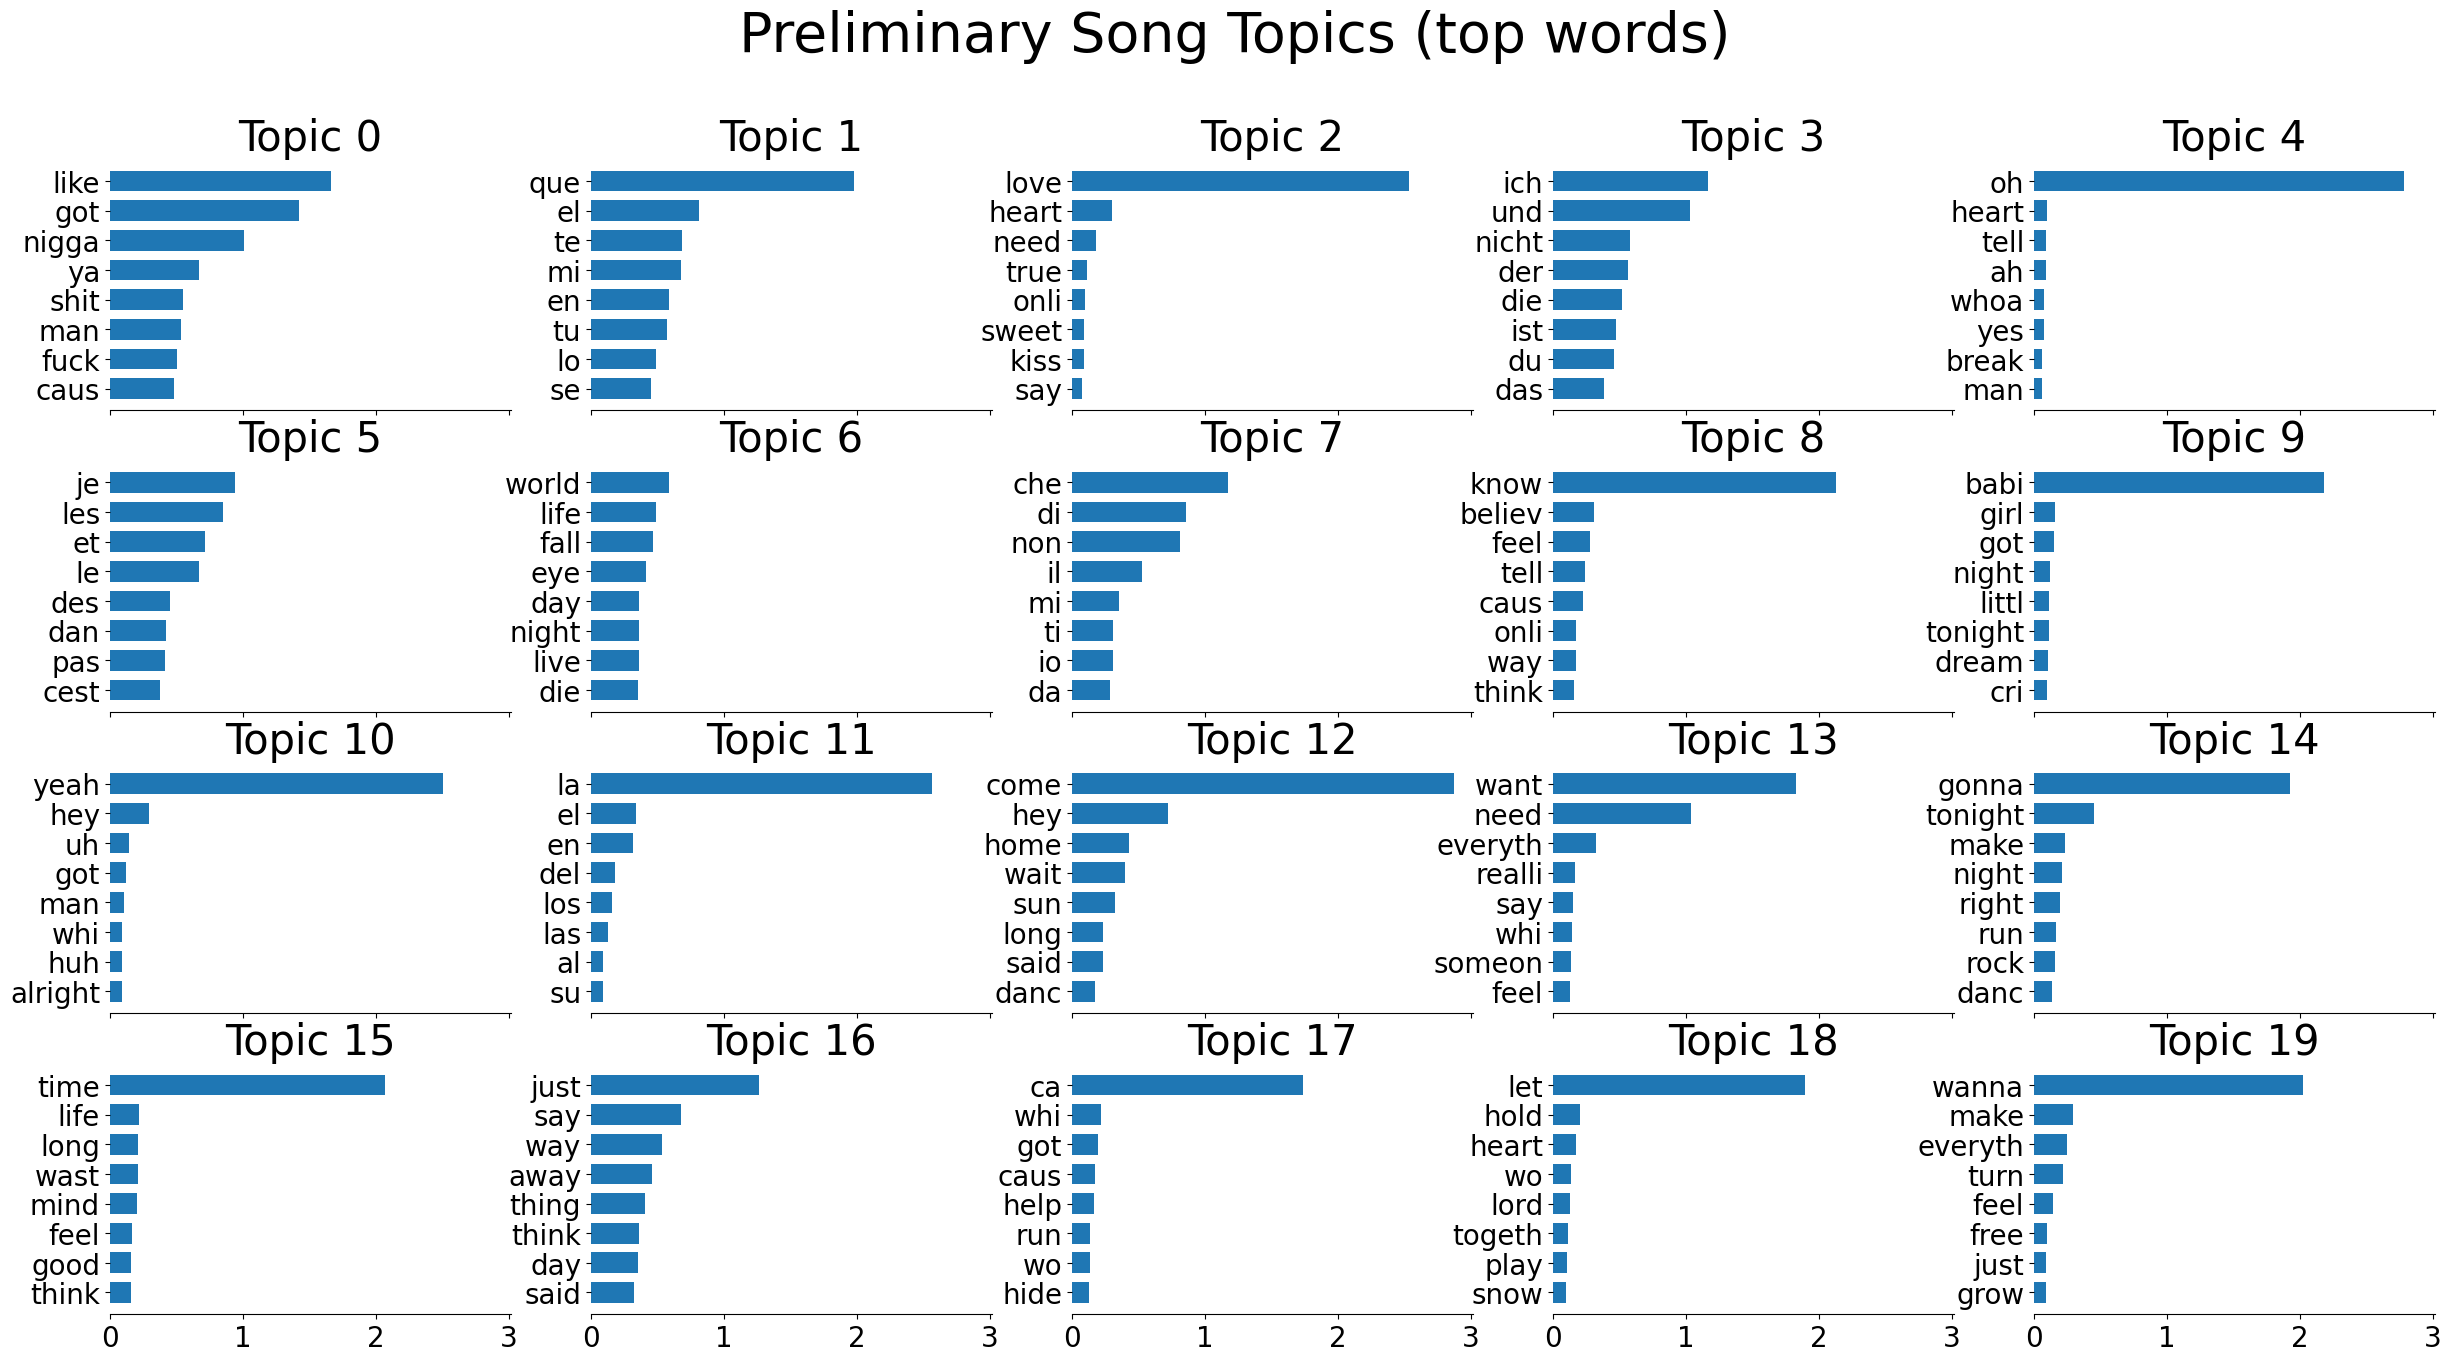

In [23]:
plot_top_words(nmf, feature_names, n_top_words=8, plot_rows=4, plot_cols=5, title='Preliminary Song Topics (top words)', norm_weights=False)

Clearly, some of these topics are comprised of songs that are primarily in languages other than English, but we can already feel some commonality within the topics. Notably, the word `'love'` is a strong feature in categorizing songs as what might be called "love songs", and other top words in that topic *feel* cohesive: `'heart'`, `'need'`, `'only'`, `'kiss'`, etc.

However, before the model is fine-tuned\*\*, the songs in the primarily non-English topics should be removed from the dataset. (They are 'valid' topics, but the focus of this project is songs in English.)

\*\* *Genuinely, this pun wasn't intended when I wrote it, but it seemed appropriate.*

### Secondary Preprocessing: removing non-English topics

Because the lyrics were stemmed by the maintainers of the original dataset, they won't align perfectly with wordbanks, such as the `words` corpus, downloaded via NLTK. To accommodate, additional 'words' that are common in the selected dataset were added to be recognized as English for the purposes of this model.

For a larger-scale version of this project, a more robust approach would be needed.

In [24]:
# Adding some 'words' to NLTK's list, mostly to account for the stemming in the main dataset.
bonus_words = [
    'someth', 'sometim', 'peopl', 'littl', 'noth', 'beauti', 'forev', 'realli',
    'believ', 'yall', 'caus', 'yall', 'shit', 'fuck', 'jesus', 'pleas', 'everybodi',
    'please', 'gotta', 'wanna', 'gonna', 'groov', 'ooh', 'ohh', 'uh', 'danc',
    'everi', 'leave', 'alon', 'anoth', 'everyth', 'cmon', 'crazi', 'mayb', 'cri',
    'babi', 'leav', 'abov', 'happi', 'darl', 'onli', 'easi', 'someon', 'prais',
    'easi', 'togeth', 'whi', 'anymor', 'goe', 'citi', 'goodby', 'feet', 'insid'
]
english_words = nltk_english_words.words() + bonus_words

# This code adjusted from this example provided by the sklearn team:
# https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html
def determine_whether_english(model, feature_names, n_top_words, min_english_percent=0.8, show_nonenglish=False):
    """
    Determine which of the topics are primarily in languages other than English.
    :param n_top_words: How many words to consider in determining the language.
    :param min_english_percent: The percent of the n_top_words that must be
     considered English for the whole topic to be considered English.
    :param show_nonenglish: (Optional) Whether to also return the words that
     were determined to be non-English.
    :return: An array of indexes, being the topics that were deemed non-English,
     corresponding to the index in `model.components_`. (If `show_nonenglish==True`,
     will also return a nested list of supposedly non-English words, one for every
     topic in `model.components_`.)
    """
    nonenglish_topic_idxs = []
    nonenglish_words_all = []

    topics = get_top_words(model, feature_names, n_top_words)
    for topic_idx, topic in enumerate(topics):
        top_words = topic['top_words']
        nonenglish_words = [word for word in top_words if word not in english_words]
        nonenglish_words_all.append(nonenglish_words)
        english_word_count = len(top_words) - len(nonenglish_words)
        if (len(top_words) - len(nonenglish_words)) / len(top_words) < min_english_percent:
            nonenglish_topic_idxs.append(topic_idx)
    if show_nonenglish:
        return nonenglish_topic_idxs, nonenglish_words_all
    return nonenglish_topic_idxs

In [25]:
nonenglish_topics = determine_whether_english(nmf, feature_names, n_top_words=20)
# Convert 0-index to 1-index, to match the above bar graphs.
print(f"Topics that are not primarily English: {', '.join([str(i + 1) for i in nonenglish_topics])}")

Topics that are not primarily English: 2, 4, 6, 8, 12


We can see from the `text` and `song_title` that this has pretty effective at filtering out non-English songs.

In [26]:
nonenglish_mask = np.isin(pred, nonenglish_topics)
dataset1_nonenglish = dataset1[nonenglish_mask]
dataset1_nonenglish.head()

,track_id,text,word_count_all,word_count_unique,song_id,artist_name,song_title
9,TRCLGUO12903C9C788,a a me no no no no que que que que que que que...,115,52,SOMIJMX12AB017ECE9,Banda Machos,Sangre de Indio
12,TRMFHBE128F4278464,a a me me just que que de de de de de de de de...,228,113,SOCNZYA12A8C13ACAD,Anis,Oisif
16,TRFZSEI128F9317742,a a a me que que que que que que de de de de d...,85,37,SOANSOC12AB0187084,Jaguares,Clavame Mejor Los Dientes
18,TRLUDVI128F1480C94,a a a a a a no no no que que que que que que q...,140,33,SOMWCJZ12A6D4FA26F,El sueño de Morfeo,Somos aire
22,TRSCJNH128F930AC9E,me me me me me no no no no no no no no no que ...,176,75,SOIGNQE12A8C140ED7,Vikki Carr,Cosas Del Amor


## Topic Extraction from predominantly English songs

Now that the dataset has been mostly stripped of songs that are not in English, the same TF-IDF and NMF process is rerun (but limited to `n_components=10` this time).

*__Content Warning:__ Profanity and slurs in the results.*

In [27]:
dataset1_english = dataset1[~nonenglish_mask]
print("English language tracks remaining:", len(dataset1_english))

English language tracks remaining: 4140


In [28]:
vec_eng = TfidfVectorizer(input='content', stop_words='english')
dt_mtx_eng = vec.fit_transform(dataset1_english['text'])
feature_names_eng = vec.get_feature_names_out()

nmf_eng = NMF(n_components=10, max_iter=500)
nmf_mtx_eng = nmf_eng.fit_transform(dt_mtx_eng)
pred_eng = np.argmax(nmf_mtx_eng, axis=1)

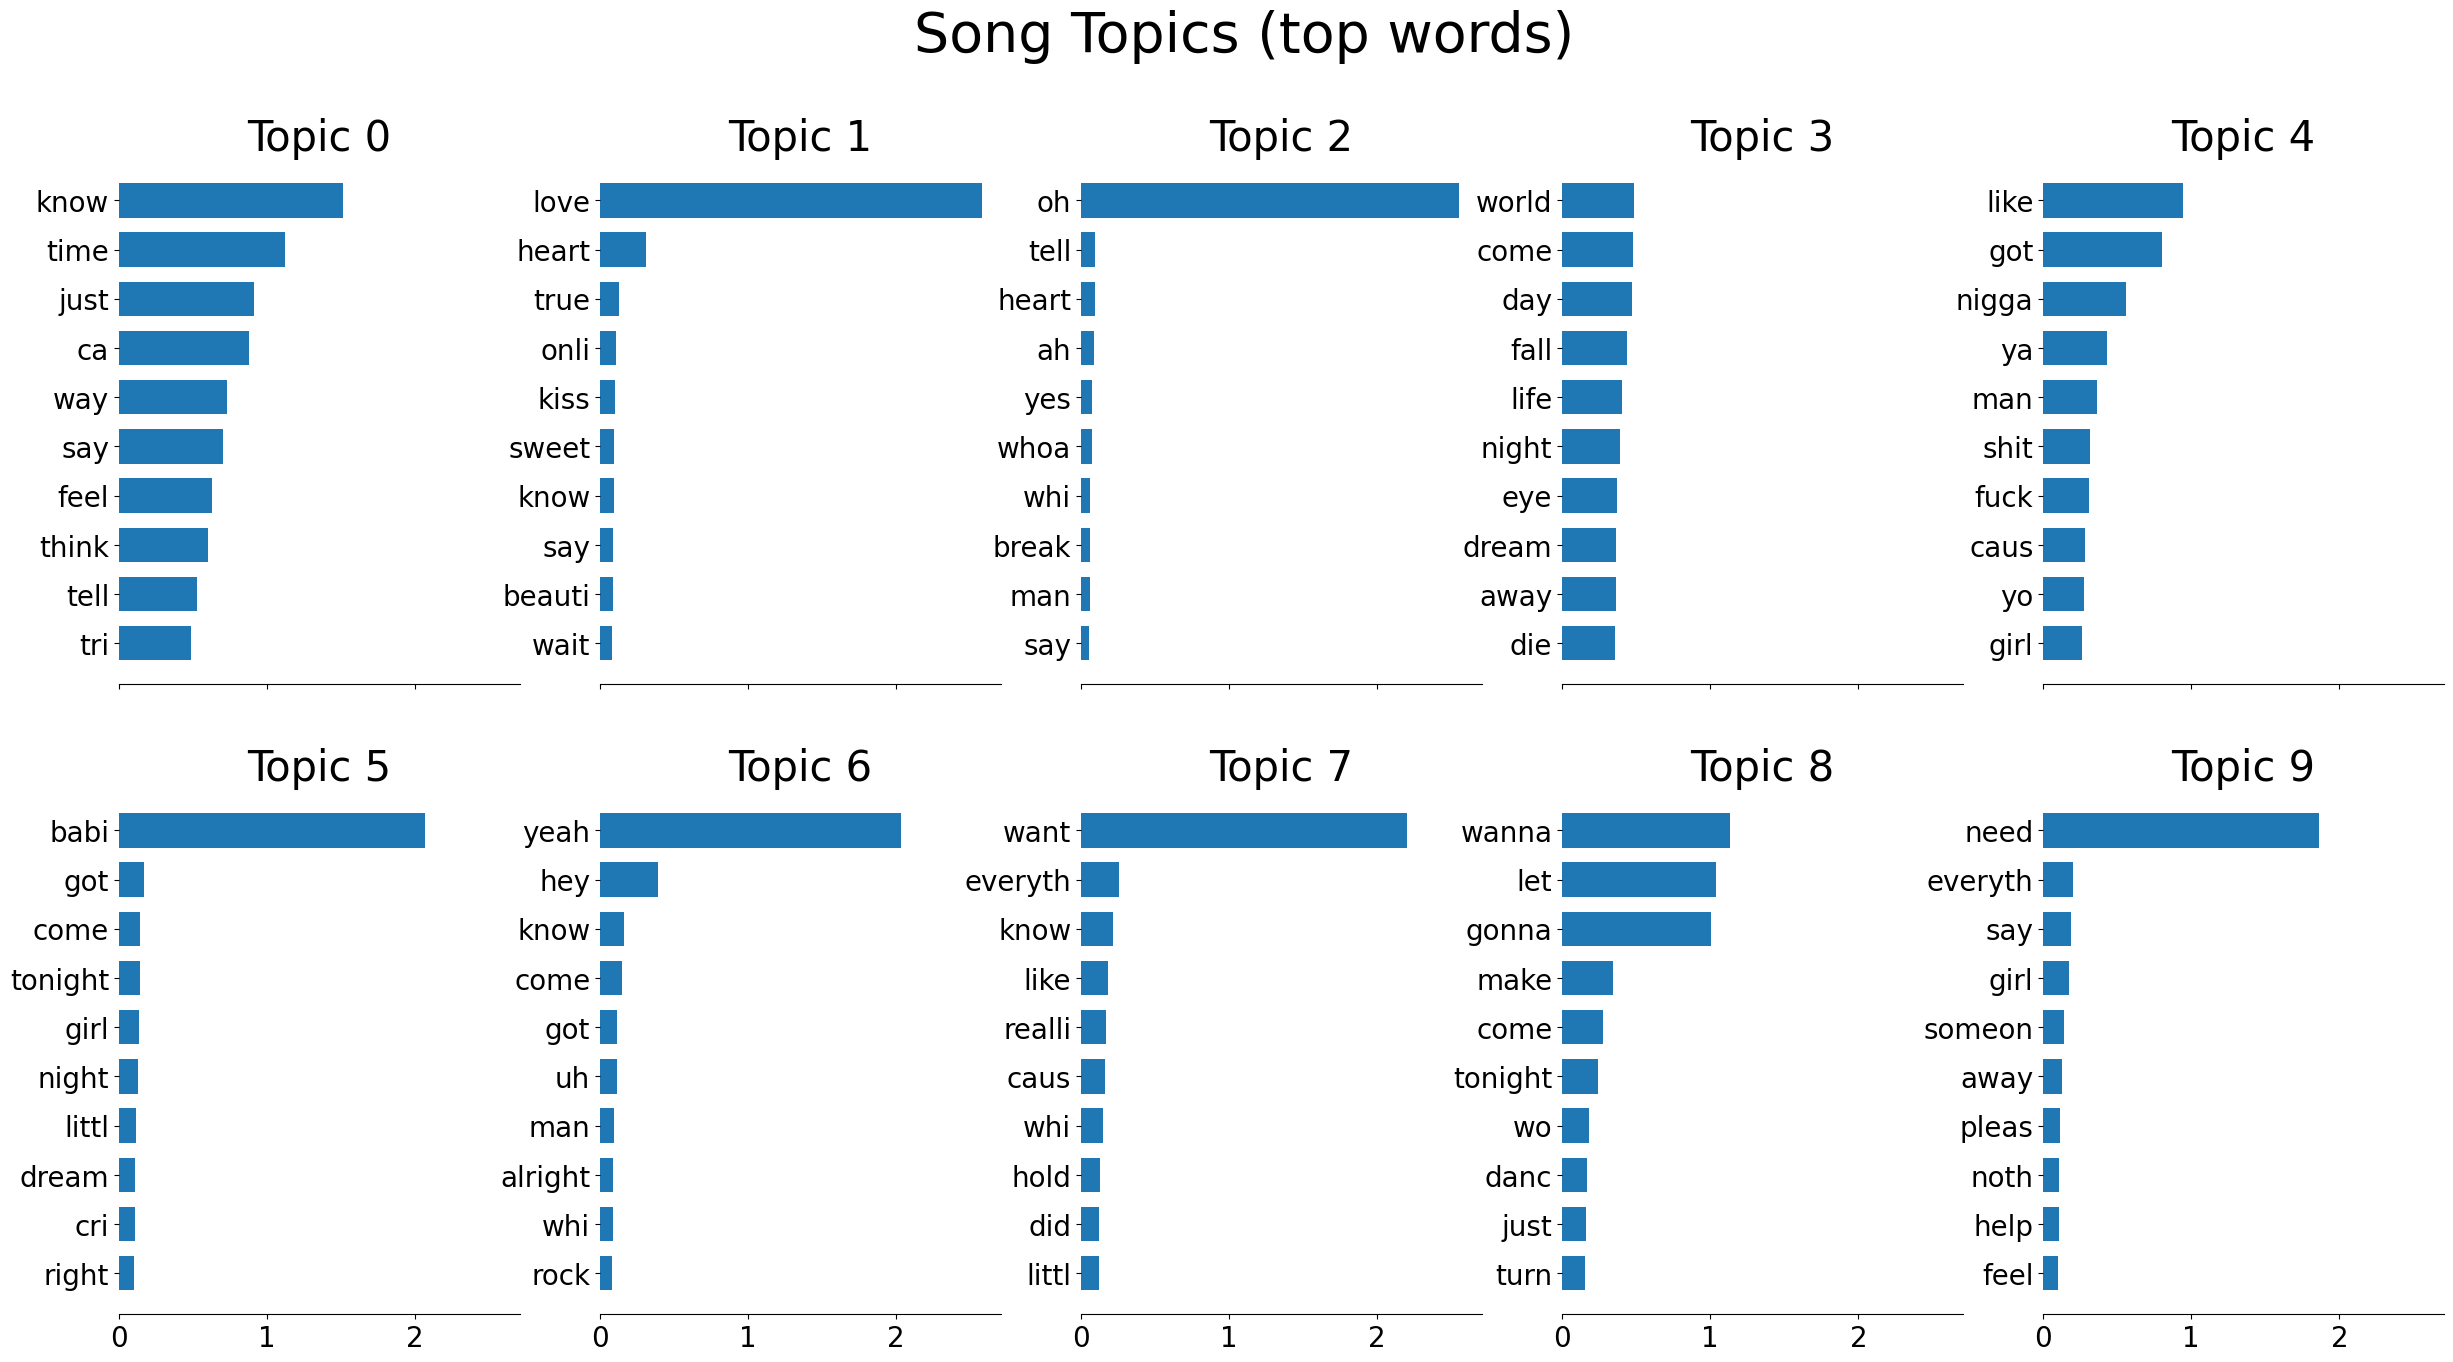

In [29]:
n_top_words=10
plot_top_words(nmf_eng, feature_names_eng, n_top_words=n_top_words, plot_rows=2, plot_cols=5, title='Song Topics (top words)', norm_weights=False)

Visually, it's clear that most of the topics are skewed by relatively few words -- e.g., `'love'` is strongly predictive of one topic in particular. In the next section, the model will be adjusted to limit the weight of individual words.

Below are calculated the overall, combined weights of the *__n__* top words in all categories, normalized to 1\*\*, summarized across all topics as the standard deviation and median.

\*\* *That is, for the chosen *__n__* top words for each of the *__m__* topics, the weights for all topics are combined then normalized to 1: `weight_of_word/sum(all_weights_of_top_words_in_any_topic)`).*

In [30]:
topics = get_top_words(nmf_eng, feature_names_eng, n_top_words=n_top_words)
weights_all = np.array([topic['weights'] for topic in topics]).flatten()
weights_all_norm = [wt/sum(weights_all) for wt in weights_all]

print(f"St.Dev. of normalized weights, using top {n_top_words} words in each category: {np.std(weights_all_norm):.4f}")
print(f"Median normalized weight, using top {n_top_words} words in each category: {np.median(weights_all_norm):.4f}")
print()
print(
    f"Median falling closer to the mean of 1/(n_top_words * m_topics) might indicate \n"
    "relatively even distribution of top words in each topic -- in this case: \n"
    f"1/({n_top_words}*{len(topics)}), or {1/(n_top_words*len(topics))}"
)


St.Dev. of normalized weights, using top 10 words in each category: 0.0129
Median normalized weight, using top 10 words in each category: 0.0043

Median falling closer to the mean of 1/(n_top_words * m_topics) might indicate 
relatively even distribution of top words in each topic -- in this case: 
1/(10*10), or 0.01


## Hyperparameter Tuning

A limit (`max_repeat`) will be imposed on the number of times a word may be counted in each song. The intuition is that a single word might be repeated for poetic or song structure reasons, and that repetition may not *necessarily* be indicative of what the song is "about". Limiting `max_repeat` will correspondingly limit the weight that a given word can have in a given song in the TF-IDF calculation.

Further, certain "sound" words (`'oh'`, `'ah'`, etc.) will be excluded. These are 'valid' words and appear prominently in some topics in the previous sections -- they are common lyrics, because music is more than the semantic content of the words (obviously). However, the next section will focus on words that might be called more 'semantically dense'.

In [31]:
drop_words = ['oh', 'ah', 'uh']
max_repeat = 3
dataset2 = get_dataset(
    available_track_ids,
    n_tracks=n_dataset_small,
    random_state=random_state,
    max_repeat=max_repeat,
    drop_words=drop_words
)
# We're using the same sample of tracks as previously, so we can
# reuse the same mask to discard non-English tracks.
dataset2_english = dataset2[~nonenglish_mask]

In [32]:
dataset2.head()

,track_id,text,word_count_all,word_count_unique
0,TRCIVZN128F147ACA3,i i i the the the you you you to to to and and...,390,130
1,TRAIULP128F4295970,i i i the the the you you you to to to a a a m...,216,72
2,TRZYFWN12903CEF239,i i i the the the you you you to to to and and...,234,78
3,TRZKWZC128F93038EB,i i i the the the you you you to to to and and...,201,67
4,TRVETVN128F147AD96,i i i the the the you you you to to to me me m...,159,53


In [33]:
vec_eng2 = TfidfVectorizer(input='content', stop_words='english')
dt_mtx_eng2 = vec.fit_transform(dataset2_english['text'])
feature_names_eng2 = vec.get_feature_names_out()

nmf_eng2 = NMF(n_components=10, max_iter=500)
nmf_mtx_eng2 = nmf_eng2.fit_transform(dt_mtx_eng2)
pred_eng2 = np.argmax(nmf_mtx_eng2, axis=1)

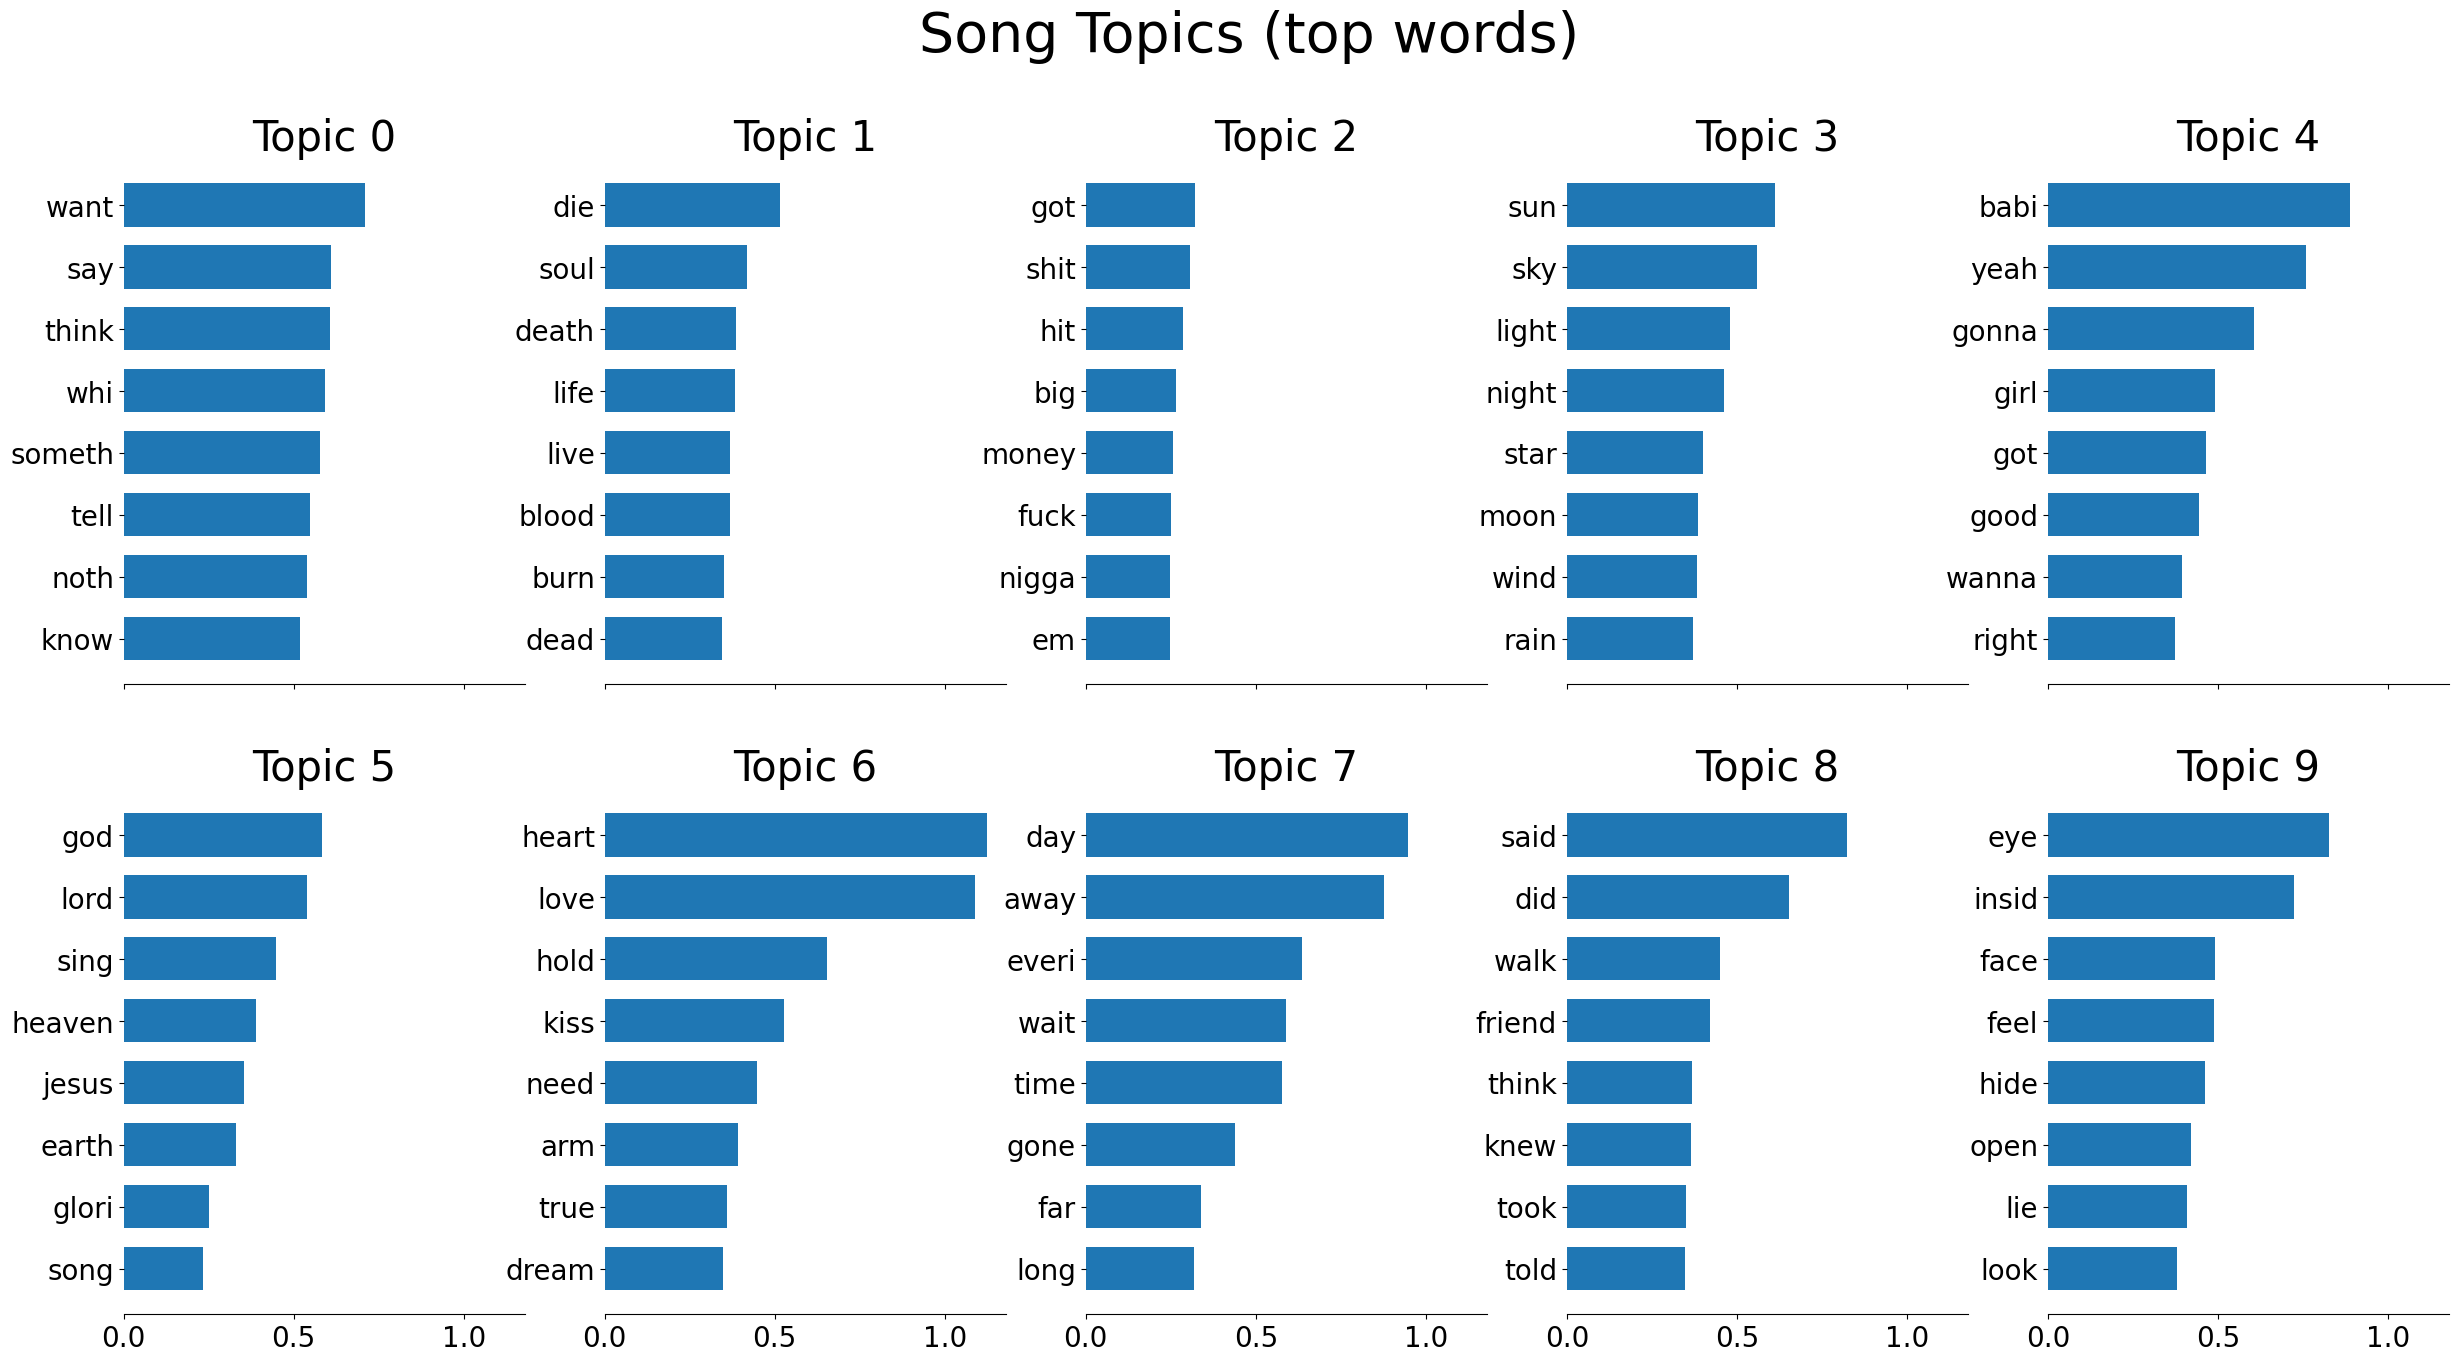

In [34]:
plot_top_words(nmf_eng2, feature_names_eng2, n_top_words=8, plot_rows=2, plot_cols=5, title='Song Topics (top words)', norm_weights=False)

It's visually obvious that the weightings of the top words in each topic are much more evenly distributed than in the previous version of the model that did not limit `max_repeat`. Below are the same median and standard deviation calculations as done previously, showing that the median normalized weight is now much closer to the mean, and the standard deviation is much smaller.

In [35]:
topics = get_top_words(nmf_eng2, feature_names_eng2, n_top_words=n_top_words)
weights_all = np.array([topic['weights'] for topic in topics]).flatten()
weights_all_norm = [wt/sum(weights_all) for wt in weights_all]

print(f"St.Dev. of normalized weights, using top {n_top_words} words in each topic: {np.std(weights_all_norm):.4f}")
print(f"Median normalized weight, using top {n_top_words} words in each topic: {np.median(weights_all_norm):.4f}")
print()
print(
    f"Median falling closer to the mean of 1/(n_top_words * m_topics) might indicate \n"
    "relatively even distribution of top words in each topic -- in this case: \n"
    f"1/({n_top_words}*{len(topics)}), or {1/(n_top_words*len(topics))}"
)

St.Dev. of normalized weights, using top 10 words in each topic: 0.0040
Median normalized weight, using top 10 words in each topic: 0.0086

Median falling closer to the mean of 1/(n_top_words * m_topics) might indicate 
relatively even distribution of top words in each topic -- in this case: 
1/(10*10), or 0.01


## Additional Layer: Categorizing Artists by Common Topic

(Caveat: The artist who recorded a track is not necessarily the artist who wrote the song.)

In [36]:
def get_sample_with_artists_full_tracklist(available_tracks, min_artists: int, min_tracks_all: int=0, min_tracks_each: int=0, random_state=None, artists_increment=5):
    """Get a sample of tracks that includes all tracks by each sampled artist."""
    artists_unique = available_tracks['artist_name'].unique()
    if min_tracks_each > 0:
        # Citation: https://stackoverflow.com/a/58536543
        artists_unique = available_tracks[available_tracks['artist_name'].map(available_tracks['artist_name'].value_counts()) >= min_tracks_each]['artist_name'].unique()
    selected_artists = set()
    m_artists = min_artists
    while True:
        new_artists = pd.DataFrame()
        new_artists['artist_name'] = artists_unique
        selected_artists.update(new_artists.sample(m_artists, random_state=random_state)['artist_name'])
        selected_tracks = available_tracks[available_tracks['artist_name'].isin(selected_artists)]
        
        if len(selected_tracks) >= min_tracks_all:
            break
        # Remove already-sampled artists from consideration.
        artists_unique = artists_unique[~np.isin(artists_unique, selected_artists)]
        # Sample this many more artists after the first, until we get enough tracks.
        m_artists = artists_increment
    return selected_tracks

In [37]:
selected_tracks = get_sample_with_artists_full_tracklist(song_info, min_artists=2000, min_tracks_all=0, min_tracks_each=5, random_state=random_state)
max_repeat = 3
drop_words = ['oh', 'ah', 'uh']
dataset3 = get_dataset(
    available_tracks=song_info,
    selected_tracks=selected_tracks,
    track_info=song_info,
    max_repeat=max_repeat,
    drop_words=drop_words
)

In [38]:
print("{len(selected_tracks))} tracks across {len(selected_tracks['artist_name'].unique())} unique artists.")

{len(selected_tracks))} tracks across {len(selected_tracks['artist_name'].unique())} unique artists.


In [39]:
# Initial processing to filter out non-English songs.
vec3 = TfidfVectorizer(input='content', stop_words='english')
dt_mtx3 = vec3.fit_transform(dataset3['text'])
feature_names3 = vec3.get_feature_names_out()

nmf3 = NMF(n_components=20, max_iter=500)
nmf3_mtx = nmf3.fit_transform(dt_mtx3)
pred3 = np.argmax(nmf3_mtx, axis=1)
nonenglish_topics3 = determine_whether_english(nmf3, feature_names3, n_top_words=20, min_english_percent=0.8, show_nonenglish=False)

nonenglish_mask3 = np.isin(pred3, nonenglish_topics3)
dataset3_english = dataset3[~nonenglish_mask3]

In [40]:
vec3_eng = TfidfVectorizer(input='content', stop_words='english')
dt_mtx3_eng = vec3_eng.fit_transform(dataset3_english['text'])
feature_names3_eng = vec3_eng.get_feature_names_out()
nmf3_eng = NMF(n_components=10, max_iter=500)
nmf3_mtx_eng = nmf3_eng.fit_transform(dt_mtx3_eng)
pred3_eng = np.argmax(nmf3_mtx_eng, axis=1)

*__Content Warning:__ Profanity and slurs in next section.*

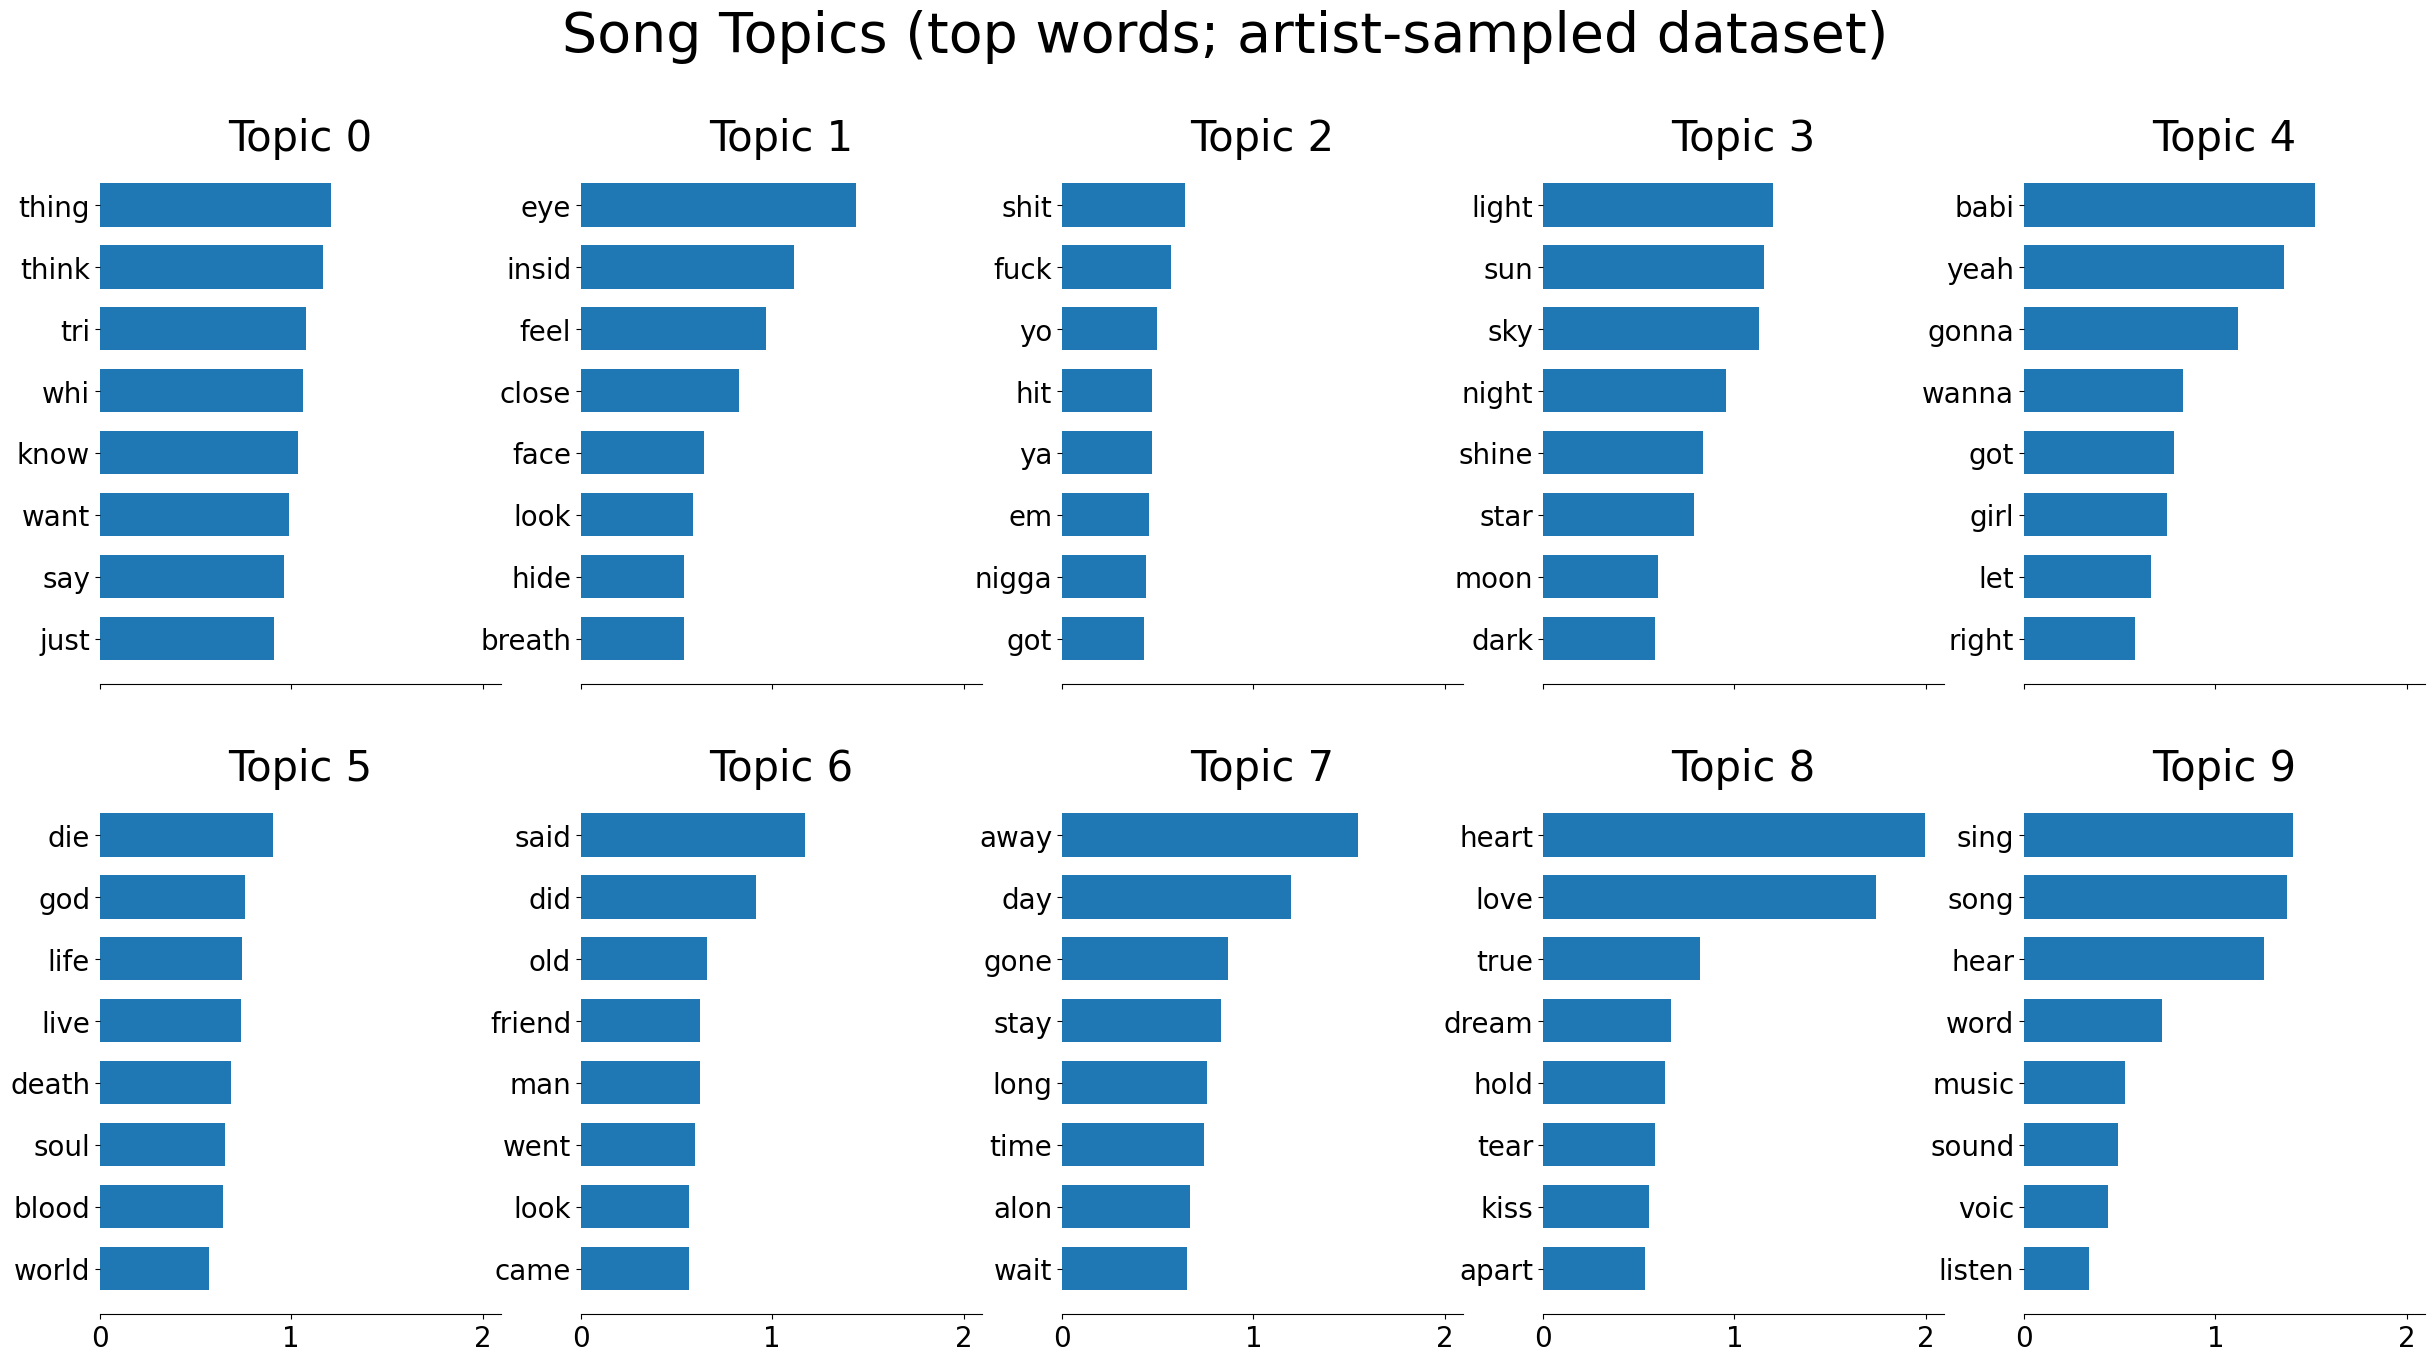

In [41]:
plot_top_words(nmf3_eng, feature_names3_eng, n_top_words=8, plot_rows=2, plot_cols=5, title='Song Topics (top words; artist-sampled dataset)', norm_weights=False)

The artists can be categorized and sorted by which topic they prefer, and how consistently they stick to that category (i.e., count of that artist's tracks within their most common topic, divided by their total number of tracks), ranging from *__1/n__* to *__1__* (where *__n__* is that artist's number of tracks).

(Not all topic groups will be printed out, for length reasons.)

In [42]:
dataset3_english.loc[:, 'topic'] = pred3_eng
topic_top_words = get_top_words(nmf3_eng, feature_names3_eng, n_top_words=8)
artist_mode = {}
artist_consistency = {}
for artist in dataset3_english['artist_name'].unique():
    artist_topics = dataset3_english[dataset3_english['artist_name'] == artist]['topic']
    mode = int(artist_topics.mode().values[0])
    consistency = sum(np.equal(artist_topics, mode)) / len(artist_topics)
    artist_mode[artist] = mode
    artist_consistency[artist] = consistency

C:\Users\james\AppData\Local\Temp\ipykernel_14488\3942990868.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset3_english.loc[:, 'topic'] = pred3_eng


In [43]:
# artist_consistency
max_artists_per_topic = 10
top_consistency_by_topic = [[] for _ in range(10)]
consistency_keys_sorted = sorted(artist_consistency.keys(), key=lambda k: artist_consistency[k], reverse=True)
for artist in consistency_keys_sorted:
    artist_main_topic = artist_mode[artist]
    if len(top_consistency_by_topic[artist_main_topic]) < max_artists_per_topic:
        top_consistency_by_topic[artist_main_topic].append((artist, artist_consistency[artist]))

In [44]:
topics_to_print = [2, 4, 5, 8, 9]
for topic_idx, artist_infos in enumerate(top_consistency_by_topic):
    if topic_idx not in topics_to_print:
        continue
    print(f"Topic #{topic_idx}... <{', '.join(topic_top_words[topic_idx]['top_words'])}, ...>")
    for artist_info in artist_infos:
        print(f" -- {artist_info[0]}: {artist_info[1]:.2f}")
    print('\n')

Topic #2... <got, nigga, em, ya, hit, yo, fuck, shit, ...>
 -- Rah Digga: 1.00
 -- Sir Mix-A-Lot: 1.00
 -- Ludacris: 1.00
 -- CMW - Compton's Most Wanted: 1.00
 -- DJ Quik: 1.00
 -- Slim Thug: 1.00
 -- Digable Planets: 1.00
 -- Ultramagnetic MC's: 1.00
 -- Rhymefest: 1.00
 -- N.W.A.: 1.00


Topic #4... <right, let, girl, got, wanna, gonna, yeah, babi, ...>
 -- Don Covay: 1.00
 -- Quiet Riot: 1.00
 -- Kapanga: 1.00
 -- James Cotton: 1.00
 -- Paris Hilton: 1.00
 -- CCCP - Fedeli Alla Linea: 1.00
 -- Ely Guerra: 1.00
 -- Negrita: 1.00
 -- Tiziano Ferro: 1.00
 -- Gilberto Gil: 1.00


Topic #5... <world, blood, soul, death, live, life, god, die, ...>
 -- Mortician: 1.00
 -- Hellbastard: 1.00
 -- Dekapitator: 1.00
 -- Deicide: 1.00
 -- Mikromusic: 1.00
 -- Shadow Host: 1.00
 -- Bestial Warlust: 1.00
 -- Ondskapt: 1.00
 -- Watain: 1.00
 -- Scorngrain: 1.00


Topic #8... <apart, kiss, tear, hold, dream, true, love, heart, ...>
 -- Sniper: 1.00
 -- Olodum: 1.00
 -- Mocedades: 1.00
 -- Saez: 1.0

In [45]:
dataset3_english[dataset3_english['topic'] == 8]

,track_id,text,word_count_all,word_count_unique,song_id,artist_name,song_title,topic
45,TROPXGV128F4284E3E,i i i the the the you you you to to to and and...,159,53,SOMUVCV12A8C1402BB,Martina Topley Bird,Ragga,8
56,TRRCXIP128F1481996,i i i the the the you you you to to to and and...,243,81,SOEEFBQ12A6D4F800B,Papa Roach,The World Around You,8
63,TRENOOG128F1459A86,i i i the the the you you you to to to and and...,246,82,SORPDJU12D02191A94,Bing Crosby,Please,8
96,TRTEKWC128F148C760,i i i the the the you you you to to to and and...,234,78,SOJTPCN12A6D4F8AAE,Dusty Springfield,Your Love Still Brings Me To My Knees,8
97,TRBZNMV128F422AD88,i i i the the the you you you to to to and and...,324,108,SOEWERY12A81C22D06,My Dying Bride,The Dark Caress,8
...,...,...,...,...,...,...,...,...
39838,TRRRHMU128F92DC211,i i i the the the you you you to to to and and...,216,72,SOCETEI12AAA15F060,Jesus On Extasy,Holy Beauty,8
39864,TRJZREH12903CE78E7,i i i the the the you you you to to to and and...,258,86,SOWMLLG12AC3DF80D8,Fra Lippo Lippi,Love Is A Lonely Harbour,8
39904,TRGDMEL128F9327338,the the the to to to and and and a a a in in i...,135,45,SOCGMIW12AB018030A,Shawn Colvin,Christmas Time Is Here,8
39909,TRRBNIT128F92E2710,the the the you you you to to to and and and i...,195,65,SODQTCQ12A8C13FF86,Yes,TO BE OVER,8


### Analysis

Clearly some genres have a strong tendancy toward one topic over another. On the other hand, the common vocabulary of one genre might not be indicative of the actual topic of a song: For some categories, the model therefore appears to be selecting genre instead of what is more intended by 'topic'. For example, profanity and reclaimed slurs in hip-hop are less commonly used in other genres, so it seems hip-hop songs are more likely to be considered by this model to be the same topic, ignoring the wide range of actual topics in the genre.

Further work on this project might entail separating the dataset by genre in order to refine topic extraction.

## Additional model: Token Count and Latent Dirichlet Allocation (LDA)

For completeness, a second model is built, similar to the first -- but instead of TF-IDF, this uses a Token Count matrix (generated by `CountVectorizer`); and instead of NMF, this model will use [Latent Diricklet Allocation (LDA)](https://towardsdatascience.com/nlp-extracting-the-main-topics-from-your-dataset-using-lda-in-minutes-21486f5aa925) to decompose the matrix.

In [51]:
# Initial pass to filter out non-English topics.
print("Running initial pass to remove non-English tracks...")
vec4 = CountVectorizer(input='content', stop_words='english')
dataset4 = dataset2_english.copy()  # Using the prior non-English mask.
dt_mtx4 = vec4.fit_transform(dataset4['text'])
feature_names4 = vec4.get_feature_names_out()

# Initially decompose to 20 components to filter non-English topics.
lda = LatentDirichletAllocation(n_components=20, random_state=random_state)
lda_mtx = lda.fit_transform(dt_mtx4)
lda_nonenglish = determine_whether_english(lda, feature_names4, n_top_words=20)
lda_pred = np.argmax(lda_mtx, axis=1)

nonenglish_mask = np.isin(lda_pred, lda_nonenglish)
dataset4_english = dataset4[~nonenglish_mask]

# Second pass with English songs.
print("Running second pass...")
vec4_eng = CountVectorizer(input='content', stop_words='english')
dt_mtx4_eng = vec4_eng.fit_transform(dataset4_english['text'])
feature_names4_eng = vec4_eng.get_feature_names_out()

lda_eng = LatentDirichletAllocation(n_components=10, random_state=random_state)
lda_mtx_eng = lda_eng.fit_transform(dt_mtx4_eng)
lda_pred = np.argmax(lda_mtx_eng, axis=1)

Running initial pass to remove non-English tracks...
Running second pass...


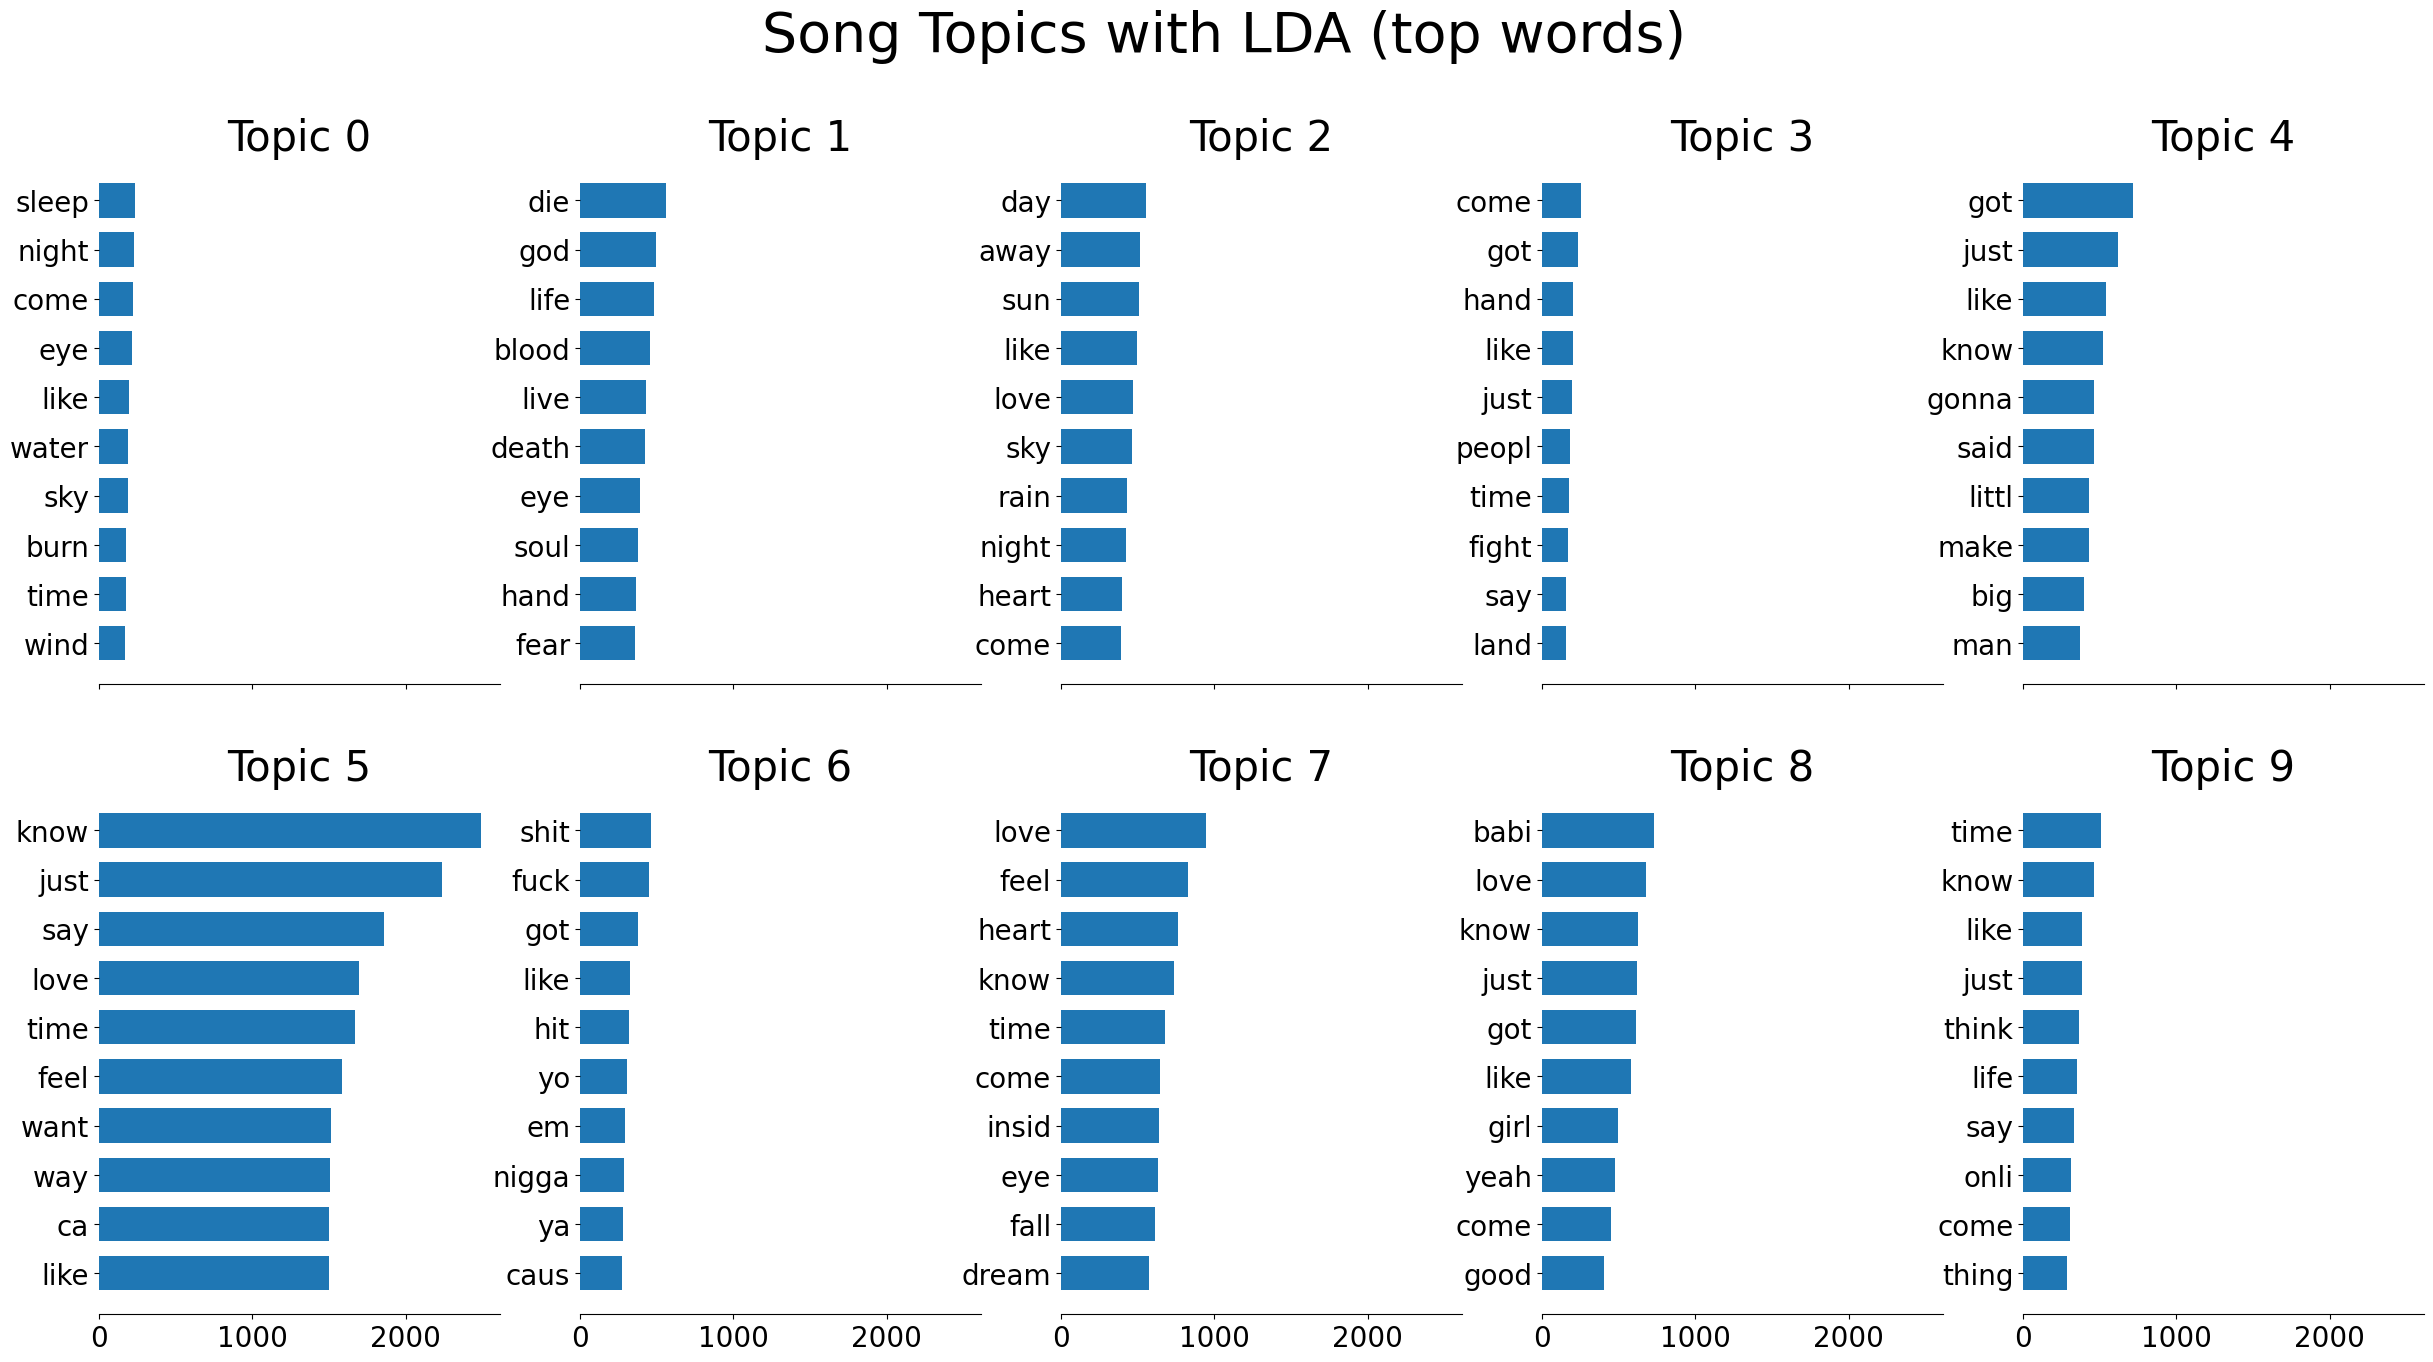

In [54]:
plot_top_words(lda_eng, feature_names4_eng, n_top_words=10, plot_rows=2, plot_cols=5, title="Song Topics with LDA (top words)")

The topics above are (subjectively speaking) less distinct than the results from the NMF model. The word `'just'` appears in the top 10 words of 5 of the 10 topics; and `'got'` appears near the top of 4 topics.

## Assessment: Coherence

__Coherence__ is a common category of metrics used in topic extraction, especially where the dataset does not contain ground truth labels. At a high level, coherence is a measure of how commonly pairs of words appear together, especially the top words (i.e., "key words") in a topic.  ([Reference](https://towardsdatascience.com/understanding-topic-coherence-measures-4aa41339634c) for the below section.)

* *__'C_V'__* coherence would give __better scores__ for words that appear __nearby__ one another (e.g., within a specified rolling window of 10 words), the intuition being that words that often appear close to one another are likely to share a common topic. However, the available dataset provided only Bag-of-Words data, meaning all context has been stripped below the document-level -- i.e., it can be determined that two words appear in the same song, but it *cannot* be determined how closely those two words occurred, meaning a rolling window cannot be employed.

* Instead, *__'U_Mass'__* coherence is used in this project, because it accounts for a pair of words co-occurring within the same document: a simple __yes or no__, regardless how far apart they occur. U_Mass coherence scores are negative, and an ideal score would be 0. Unfortunately, U_Mass scores are somewhat arbitrary in size and do not provide context for the size of the score -- that is, a score of -20 in one model is not necessarily better than a score of -30 in another model. However, an optimal score (nearest to 0) can be achieved for a given dataset by tweaking the number of topics extracted and presumably other hyperparameters. ([Original UMass paper here.](https://mimno.infosci.cornell.edu/papers/mimno-semantic-emnlp.pdf))


*__Caveat:__* In general, coherence is not a perfect metric, because the algorithm can't actually understand whether the topic is good or bad, as a human would deem it. Therefore, it is often supplemented with subjective human judgment (e.g., a subject matter expert), which has primarily been how the models have been assessed above.



In [48]:
# Apparently, tmtooklit provides a coherence_metric_gensim() function that could calculate
# the u_mass coherence with this bag-of-words dataset, but there were installation issues.
# (It requires a lower version of Python than I want to use.)

# Citation: ChatGPT provided guidance on how to implement u_mass coherence calculations.

def u_mass_coherence(dt_mtx, top_words_idxs):
    pair_count = {}
    top_words_idxs = set(top_words_idxs)
    individual_count = {idx: 0 for idx in top_words_idxs}
    # Iterate over every row in Document-Term Matrix, counting co-occurring words
    # (represented by their indexes in the DTM) in each row.
    for doc_features in dt_mtx:
        nonzero_idxs = doc_features.nonzero()[1]
        top_co_occurring_idxs = set(nonzero_idxs).intersection(top_words_idxs)
        for idx in top_co_occurring_idxs:
            individual_count[idx] += 1
        for pair in combinations(top_co_occurring_idxs, 2):
            # Will do nothing if len <= 1
            pair = tuple(sorted(pair))
            pair_count.setdefault(pair, 0)
            pair_count[pair] += 1

    total_pair_count = sum(pair_count.values())
    coherence = 0
    for pair, count in pair_count.items():
        # The original U_Mass formula includes a +1 "smoothing count" to avoid
        # taking the log of 0, but we're including only non-zero counts, so it
        # is omitted.
        i, j = pair
        coherence += np.log(count / individual_count[i])
    return coherence


def all_u_mass_coherence(model, dt_mtx, n_top_words=10):
    top_words_each_topic = []
    top_words_idxs_each_topic = []
    # This section adapted from sklearn example cited elsewhere.
    for topic in model.components_:
        top_words_idxs = topic.argsort()[-n_top_words:]
        top_words_idxs_each_topic.append(top_words_idxs)
    coherences = []
    for i, top_words_idxs in enumerate(top_words_idxs_each_topic):
        coher = u_mass_coherence(dt_mtx, top_words_idxs)
        coherences.append(coher)
        print(f"Topic {i} coherence: {coher:.3f}")
    return coherences
        

In [53]:
n_top_words_umass = 10

# Re-vectorize using bag-of-words (Y/N), rather than TF-IDF (weighted).
# Will be the same document-term labels, although the contents will be different.
coherence_vec1 = CountVectorizer(stop_words='english')
ds1_td_mtx = coherence_vec1.fit_transform(dataset1_english['text'])

coherence_vec23 = CountVectorizer(stop_words='english')
ds23_td_mtx = coherence_vec23.fit_transform(dataset2_english['text'])

print("NMF - First Dataset, minimally preprocessed")
cohs = all_u_mass_coherence(nmf_eng, ds1_td_mtx, n_top_words=n_top_words_umass)
print(f"Mean: {np.mean(cohs):.3f}")
print('\n')

print("NMF - First Dataset, cull 'oh', 'ah', 'uh'; max_repeat=3")
cohs = all_u_mass_coherence(nmf_eng2, ds23_td_mtx, n_top_words=n_top_words_umass)
print(f"Mean: {np.mean(cohs):.3f}")
print('\n')

print("LDA - First Dataset, cull 'oh', 'ah', 'uh'; max_repeat=3")
cohs = all_u_mass_coherence(lda_eng, ds23_td_mtx, n_top_words=n_top_words_umass)
print(f"Mean: {np.mean(cohs):.3f}")
print('\n')

coherence_vec4 =  CountVectorizer(stop_words='english')
ds4_td_mtx = coherence_vec4.fit_transform(dataset3_english['text'])

print("NMF - Artist-sampled Dataset, cull 'oh', 'ah', 'uh'; max_repeat=3")
cohs = all_u_mass_coherence(nmf3_eng, dt_mtx3_eng, n_top_words=n_top_words_umass)
print(f"Mean: {np.mean(cohs):.3f}")

NMF - First Dataset, minimally preprocessed
Topic 0 coherence: -50.673
Topic 1 coherence: -79.780
Topic 2 coherence: -92.963
Topic 3 coherence: -68.632
Topic 4 coherence: -77.355
Topic 5 coherence: -75.808
Topic 6 coherence: -82.141
Topic 7 coherence: -64.711
Topic 8 coherence: -72.976
Topic 9 coherence: -83.993
Mean: -74.903


NMF - First Dataset, cull 'oh', 'ah', 'uh'; max_repeat=3
Topic 0 coherence: -62.524
Topic 1 coherence: -73.671
Topic 2 coherence: -66.395
Topic 3 coherence: -90.268
Topic 4 coherence: -60.989
Topic 5 coherence: -99.879
Topic 6 coherence: -75.689
Topic 7 coherence: -81.711
Topic 8 coherence: -85.267
Topic 9 coherence: -79.521
Mean: -77.591


LDA - First Dataset, cull 'oh', 'ah', 'uh'; max_repeat=3
Topic 0 coherence: -9.436
Topic 1 coherence: -30.866
Topic 2 coherence: -32.807
Topic 3 coherence: -29.574
Topic 4 coherence: -51.234
Topic 5 coherence: -51.719
Topic 6 coherence: -26.175
Topic 7 coherence: -34.830
Topic 8 coherence: -37.508
Topic 9 coherence: -20.608
M

It seems the preprocessing between the first and second model resulted in somewhat worse coherence. But recall that U_Mass coherence scores are not consistent across model types.

# Conclusion

TF-IDF and NMF are a common pair of tools for topic extraction for good reason. Even with song lyrics (text that is more poetic than prose), the model is capable of deducing topics. Absent ground truth in the dataset, the success of this model was assessed subjectively by the top words in each category, and (somewhat less subjectively) by evening out the distribution of the *n* top words in each extracted topic. Specifically, limiting the maximum number of times a word can repeat allowed for a wider array of words to influence the topic categorization while still allowing repeated words to hold more weight than words that appear in a given song only once.

# Citations

__Dataset:__

Thierry Bertin-Mahieux, Daniel P.W. Ellis, Brian Whitman, and Paul Lamere. 
*The Million Song Dataset.* In Proceedings of the 12th International Society
for Music Information Retrieval Conference (ISMIR 2011), 2011. < http://millionsongdataset.com >


__Other references:__

* David Mimno, Hanna Wallach, Edmund Talley, Miriam Leenders, and Andrew McCallum. (2011). *Optimizing Semantic Coherence in Topic Models*. EMNLP 2011 - Conference on Empirical Methods in Natural Language Processing, Proceedings of the Conference. 262-272. < https://mimno.infosci.cornell.edu/papers/mimno-semantic-emnlp.pdf >
* https://medium.com/blend360/topic-modelling-a-comparison-between-lda-nmf-bertopic-and-top2vec-part-i-3c16372d51f0
* https://stackoverflow.com/questions/29099621/how-to-find-out-wether-a-word-exists-in-english-using-nltk
* https://scikit-learn.org/stable/auto_examples/applications/plot_topics_extraction_with_nmf_lda.html
* https://stackoverflow.com/a/58536543
* https://towardsdatascience.com/nlp-extracting-the-main-topics-from-your-dataset-using-lda-in-minutes-21486f5aa925


The following references weren't really used for this project, but I had referred to them while learning about TF-IDF and NMF during another class project, so I include them here for completeness. Links to some these were included in the initial discussion of NMF and/or TF-IDF.

* https://www.geeksforgeeks.org/understanding-tf-idf-term-frequency-inverse-document-frequency/#
* https://www.learndatasci.com/glossary/tf-idf-term-frequency-inverse-document-frequency/
* https://iq.opengenus.org/topic-modeling-nmf/